In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense

In [3]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\Titanic_data\Titanic-Dataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title = "Titanic", explorative = True)
profile.to_file('titanic_data.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:01<00:00,  8.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
df.drop(columns=["PassengerId", "Name", "Ticket", 'Cabin'],inplace = True)

In [7]:
df['Age'].skew()

np.float64(0.38910778230082704)

In [8]:
%matplotlib inline

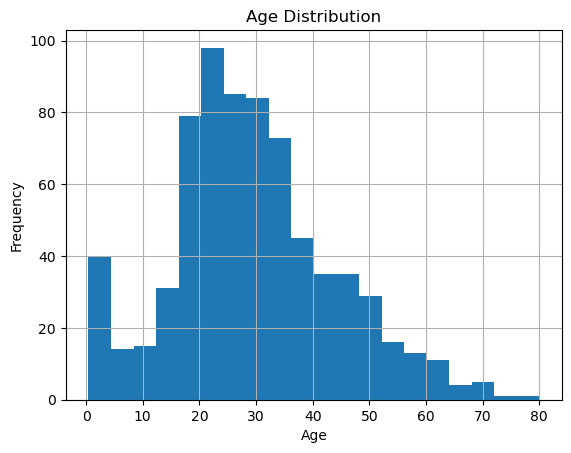

In [9]:
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [10]:
df['Age'].fillna(df['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'mean')
df['Age'] = imputer.fit_transform(df[["Age"]])

In [12]:
df['Age'].isnull().sum()

np.int64(0)

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex']= le.fit_transform(df['Sex'])

In [14]:
df['Sex'].head()

0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64

In [15]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
df['Embarked'].isnull().sum()

np.int64(0)

In [17]:
df['Embarked']= le.fit_transform(df['Embarked'])

In [18]:
df['Embarked'].head()

0    2
1    0
2    2
3    2
4    2
Name: Embarked, dtype: int64

In [19]:
df['Pclass'] = df['Pclass'].astype(int)

In [20]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [21]:
X = df.drop(columns = ['Survived'])
y = df['Survived']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model = Sequential()

In [25]:
model.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

c:\Users\Ali\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.get_weights()

[array([[-8.72087479e-03,  1.58655882e-01,  2.62061805e-01,
         -1.87180072e-01, -2.64617205e-02,  2.47892231e-01,
          2.78935164e-01,  3.86950374e-03, -1.82198882e-02,
          1.44730508e-01, -1.67662829e-01,  1.41153008e-01,
          2.44495898e-01, -2.72525191e-01,  2.63231248e-01,
          2.29941636e-01,  1.98795766e-01, -1.58659711e-01,
          2.27717251e-01,  2.11542398e-01, -2.55513191e-02,
          2.71736681e-02,  3.51819098e-02, -4.84651178e-02,
         -3.90900970e-02, -8.59648734e-02, -5.29249907e-02,
          1.40100718e-03, -1.23545200e-01,  1.80476665e-01,
          9.89690423e-03,  4.50609028e-02, -4.88744229e-02,
         -8.36524367e-02,  1.60365254e-01, -4.43271995e-02,
          1.01503432e-01,  2.50401884e-01, -2.50356764e-01,
         -1.10535666e-01, -7.68708438e-02, -1.27021477e-01,
          1.48409992e-01,  2.63758600e-02,  9.18551981e-02,
         -3.84769142e-02,  3.68051529e-02, -2.23677695e-01,
          2.11027265e-02,  1.37267590e-0

In [28]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(loss = 'binary_crossentropy', optimizer = optimizer, metrics = ['accuracy'])

In [29]:
history = model.fit(X_train_scaled, y_train, epochs = 100, batch_size = 32, validation_split= 0.2, verbose = 1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 330ms/step - accuracy: 0.7417 - loss: 0.5918 - val_accuracy: 0.7762 - val_loss: 0.5366
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.7926 - loss: 0.5246 - val_accuracy: 0.8042 - val_loss: 0.4793
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8067 - loss: 0.4829 - val_accuracy: 0.8042 - val_loss: 0.4382
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8049 - loss: 0.4568 - val_accuracy: 0.8252 - val_loss: 0.4137
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8067 - loss: 0.4427 - val_accuracy: 0.8252 - val_loss: 0.4011
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8155 - loss: 0.4331 - val_accuracy: 0.8322 - val_loss: 0.3964
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8207 - loss: 0.4256 - val_accuracy: 0.8252 - val_loss: 0.3992
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.8225 - loss: 0.4208 - val_accuracy:

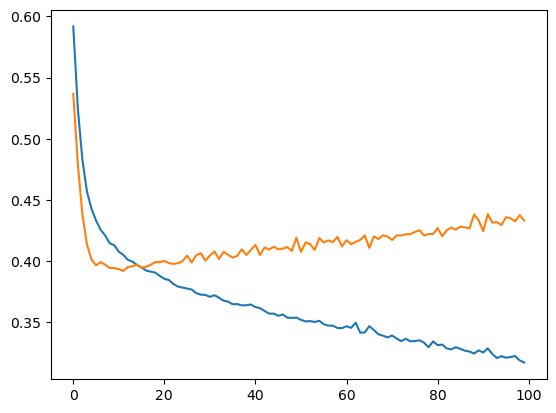

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

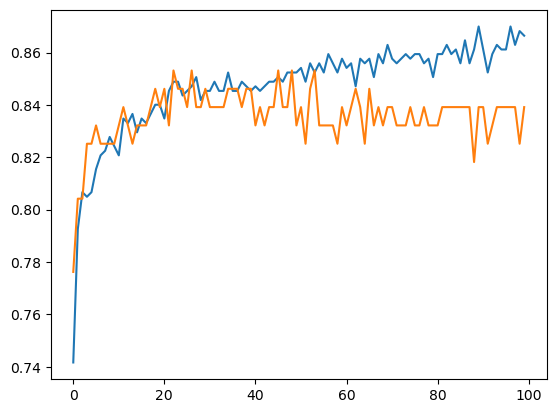

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

## Early Stopping

In [32]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss', patience = 30, restore_best_weights = True)


In [33]:
history_es = model.fit(X_train_scaled, y_train, epochs = 100, validation_split=0.2, callbacks = [early_stop],verbose = 1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8647 - loss: 0.3175 - val_accuracy: 0.8252 - val_loss: 0.4335
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8629 - loss: 0.3163 - val_accuracy: 0.8182 - val_loss: 0.4381
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - accuracy: 0.8612 - loss: 0.3150 - val_accuracy: 0.8392 - val_loss: 0.4364
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8682 - loss: 0.3177 - val_accuracy: 0.8252 - val_loss: 0.4410
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8647 - loss: 0.3153 - val_accuracy: 0.8462 - val_loss: 0.4341
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8647 - loss: 0.3157 - val_accuracy: 0.8322 - val_loss: 0.4374
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8735 - loss: 0.3145 - val_accuracy: 0.8392 - val_loss: 0.4373
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.8629 - loss: 0.3188 - val_accuracy: 

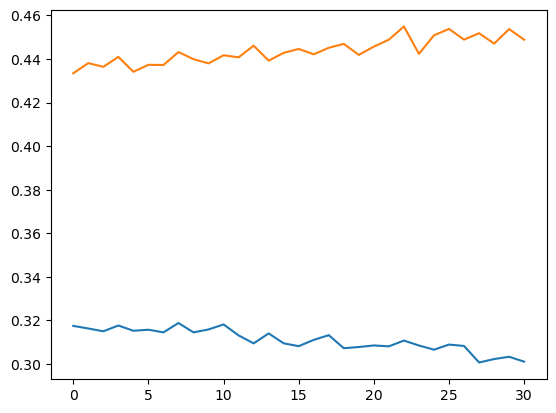

In [34]:
plt.plot(history_es.history['loss'])
plt.plot(history_es.history['val_loss'])

## Model too Complex
- Titanic Small Dataset so add less hidden layer
- Add Regualarizarion and Dropout

In [35]:
from tensorflow.keras import regularizers
model = Sequential([
    Dense(32,activation = 'relu',input_shape = (X_train.shape[1],),kernel_regularizer = regularizers.l2(0.001)),
    Dense(16,activation = 'relu', kernel_regularizer = regularizers.l2(0.001)),
    Dense(1, activation = 'sigmoid')
])
from tensorflow.keras.optimizers import Adam
optimizers = Adam(learning_rate = 0.001)
model.compile(loss = 'binary_crossentropy', optimizer = optimizers, metrics = [ 'accuracy'])

history_reg = model.fit(X_train_scaled,y_train, epochs = 100, verbose = 1, validation_split =0.2)


Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.6257 - loss: 0.7209 - val_accuracy: 0.6853 - val_loss: 0.6726
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.6801 - loss: 0.6682 - val_accuracy: 0.7273 - val_loss: 0.6258
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7188 - loss: 0.6257 - val_accuracy: 0.7622 - val_loss: 0.5818
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7417 - loss: 0.5882 - val_accuracy: 0.7692 - val_loss: 0.5481
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7592 - loss: 0.5581 - val_accuracy: 0.8042 - val_loss: 0.5204
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7926 - loss: 0.5342 - val_accuracy: 0.8392 - val_loss: 0.5000
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8049 - loss: 0.5164 - val_accuracy: 0.8252 - val_loss: 0.4871
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8067 - loss: 0.5036 - val_accuracy:

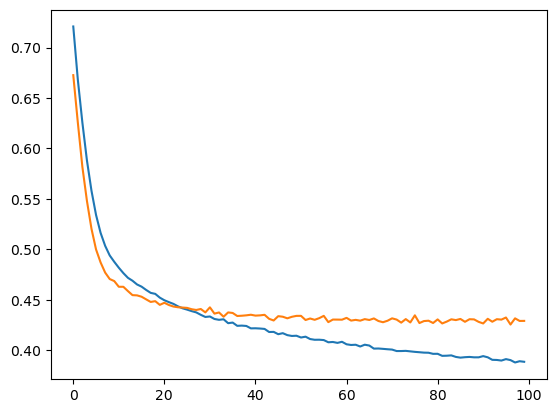

In [36]:
plt.plot(history_reg.history['loss'])
plt.plot(history_reg.history['val_loss'])

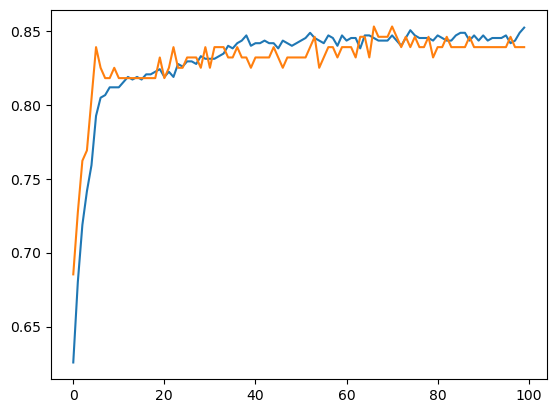

In [37]:
plt.plot(history_reg.history['accuracy'])
plt.plot(history_reg.history['val_accuracy'])

In [38]:
from keras.layers import Dropout
model = Sequential([
    Dense(32,activation = 'relu',input_shape = (X_train.shape[1],),kernel_regularizer = regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(16,activation = 'relu', kernel_regularizer = regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(1, activation = 'sigmoid')
])
from tensorflow.keras.optimizers import Adam
optimizers = Adam(learning_rate = 0.001)
model.compile(loss = 'binary_crossentropy', optimizer = optimizers, metrics = [ 'accuracy'])

history_drop = model.fit(X_train_scaled,y_train, epochs = 100, verbose = 1, validation_split =0.2)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - accuracy: 0.6028 - loss: 0.7500 - val_accuracy: 0.6573 - val_loss: 0.6437
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.6520 - loss: 0.6543 - val_accuracy: 0.7133 - val_loss: 0.5979
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6643 - loss: 0.6426 - val_accuracy: 0.7413 - val_loss: 0.5614
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7083 - loss: 0.6179 - val_accuracy: 0.7552 - val_loss: 0.5349
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7346 - loss: 0.5891 - val_accuracy: 0.7622 - val_loss: 0.5120
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7329 - loss: 0.5624 - val_accuracy: 0.7902 - val_loss: 0.4970
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7311 - loss: 0.5834 - val_accuracy: 0.8322 - val_loss: 0.4862
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.7698 - loss: 0.5288 - val_accuracy:

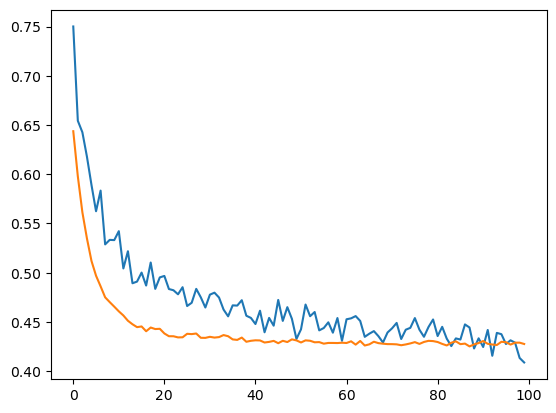

In [39]:
plt.plot(history_drop.history['loss'])
plt.plot(history_drop.history['val_loss'])

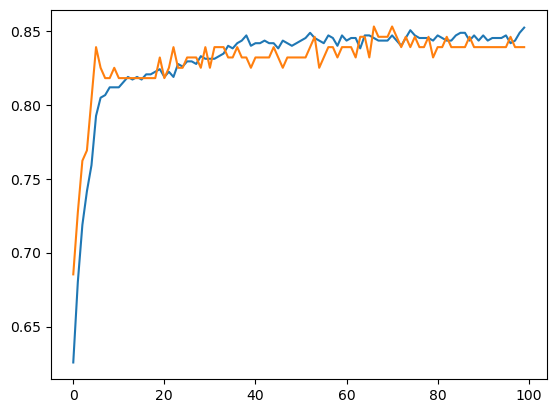

In [40]:
plt.plot(history_reg.history['accuracy'])
plt.plot(history_reg.history['val_accuracy'])

In [43]:
y_log = model.predict(X_test_scaled)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step


In [44]:
y_pred =np.where(y_log>0.5,1,0)

In [45]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, y_pred)
print(score)

0.8212290502793296
